# Dataset Strategy — Cross-Generator Validation for Biosignature Detection

**ExoBiome** | HACK-4-SAGES 2026

Why using two independent radiative transfer codes (TauREx + POSEIDON) makes our ML pipeline scientifically robust.

## 1. The Problem: Simulator Bias

A transmission spectrum is synthetic — generated by a radiative transfer code that solves:

$$\delta(\lambda) = \frac{R_p^2}{R_s^2} + \frac{2}{R_s^2} \int_{0}^{z_{max}} (R_p + z)\left(1 - e^{-\tau(\lambda, z)}\right) dz$$

where $\tau(\lambda, z)$ is the optical depth at wavelength $\lambda$ and altitude $z$.

**The risk:** If we train our classifier on spectra from only one code (e.g., TauREx), it might learn:
- Real atmospheric physics (what we want)
- Numerical artifacts specific to TauREx's implementation (what we don't want)

**The solution:** Train on code A (TauREx), validate on code B (POSEIDON). If the model generalizes across generators → it learned physics, not artifacts.

This is the same principle as **domain adaptation** in ML: training and test distributions should differ in irrelevant ways (simulator implementation) but agree on relevant ways (atmospheric physics).

## 2. TauREx vs POSEIDON — Are They Interchangeable?

Two independent radiative transfer codes, built by different teams, using the same underlying physics.

### Input Parameters (Atmosphere Definition)

| Parameter | TauREx 3 (ABC/ADC2023) | POSEIDON | Match? |
|-----------|----------------------|----------|--------|
| Planet radius | `planet_radius` (Rp) | `R_p` (Rp) | Identical |
| Temperature | `planet_temp` (K, isothermal) | `T` (K, isothermal or P-T profile) | Identical |
| H₂O abundance | `log_H2O` (log₁₀ VMR) | `log_X` (log₁₀ VMR) | Identical |
| CO₂ abundance | `log_CO2` (log₁₀ VMR) | `log_X` (log₁₀ VMR) | Identical |
| CO abundance | `log_CO` (log₁₀ VMR) | `log_X` (log₁₀ VMR) | Identical |
| CH₄ abundance | `log_CH4` (log₁₀ VMR) | `log_X` (log₁₀ VMR) | Identical |
| NH₃ abundance | `log_NH3` (log₁₀ VMR) | `log_X` (log₁₀ VMR) | Identical |
| Fill gas | H₂/He (ratio 0.17) | H₂/He (configurable) | Identical |
| Pressure range | 10 bar to 10⁻¹⁰ bar, 100 layers | Configurable, typically 100 layers | Equivalent |

### Output (Transmission Spectrum)

| Property | TauREx 3 | POSEIDON | Match? |
|----------|----------|----------|--------|
| Observable | Transit depth (Rp/Rs)² | Transit depth (Rp/Rs)² | Identical |
| Wavelength range | 1.1–7.8 μm (Ariel Tier-2) | Arbitrary (rebinnable) | Compatible |
| Spectral bins | 52 (fixed Ariel grid) | Any resolution (rebin with SpectRes) | Compatible |
| Noise model | ArielRad plugin | None (add manually) | Different but separable |

### Physics Engine

| Component | TauREx 3 | POSEIDON | Match? |
|-----------|----------|----------|--------|
| Radiative transfer | 1D plane-parallel | 1D/2D/3D (TRIDENT) | Equivalent at 1D |
| Line lists | ExoMol (POKAZATEL, CoYuTe, MM, Li2015, UCL-4000) | ExoMol (same line lists) | Same source |
| Opacity resolution | R ~ 15,000 (ExoMolOP) | R ~ 10⁶ (Cthulhu) | Different, converges at R<1000 |
| CIA | H₂-H₂, H₂-He | H₂-H₂, H₂-He | Identical |
| Rayleigh scattering | Yes | Yes | Identical |
| Clouds/hazes | Parametric deck + haze | Parametric + Mie | Both support simple models |

### Ground Truth Labels

| Label | TauREx format | POSEIDON format | Conversion needed? |
|-------|--------------|-----------------|-------------------|
| `log_H2O` | log₁₀(VMR), range [-9, -3] | log₁₀(VMR) | None |
| `log_CO2` | log₁₀(VMR), range [-9, -4] | log₁₀(VMR) | None |
| `log_CO` | log₁₀(VMR), range [-6, -3] | log₁₀(VMR) | None |
| `log_CH4` | log₁₀(VMR), range [-9, -3] | log₁₀(VMR) | None |
| `log_NH3` | log₁₀(VMR), range [-9, -3] | log₁₀(VMR) | None |

**Key finding: All 5 biosignature gas labels use identical parameterization. Zero conversion needed.**

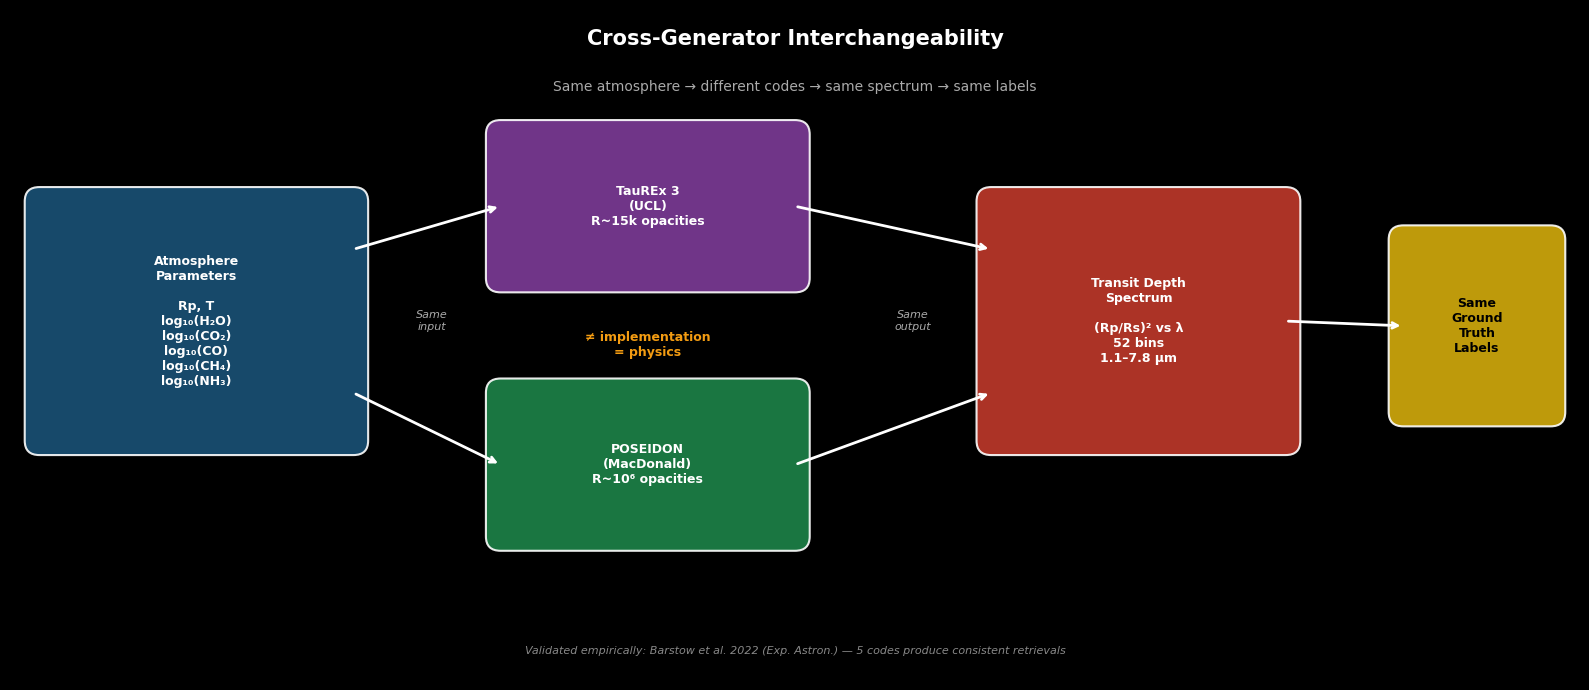

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')

def add_box(ax, xy, w, h, text, color='#2c3e50', textcolor='white', fontsize=10, alpha=0.9):
    box = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.15", facecolor=color, edgecolor='white',
                         linewidth=1.5, alpha=alpha)
    ax.add_patch(box)
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha='center', va='center',
            fontsize=fontsize, color=textcolor, fontweight='bold', wrap=True)

def add_arrow(ax, start, end, color='white'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

add_box(ax, (0.3, 2.5), 3.2, 2.5,
        'Atmosphere\nParameters\n\nRp, T\nlog₁₀(H₂O)\nlog₁₀(CO₂)\nlog₁₀(CO)\nlog₁₀(CH₄)\nlog₁₀(NH₃)',
        color='#1a5276', fontsize=9)

add_box(ax, (5, 4.2), 3, 1.5,
        'TauREx 3\n(UCL)\nR~15k opacities',
        color='#7d3c98', fontsize=9)

add_box(ax, (5, 1.5), 3, 1.5,
        'POSEIDON\n(MacDonald)\nR~10⁶ opacities',
        color='#1e8449', fontsize=9)

add_box(ax, (10, 2.5), 3, 2.5,
        'Transit Depth\nSpectrum\n\n(Rp/Rs)² vs λ\n52 bins\n1.1–7.8 μm',
        color='#c0392b', fontsize=9)

add_box(ax, (14.2, 2.8), 1.5, 1.8,
        'Same\nGround\nTruth\nLabels',
        color='#d4ac0d', textcolor='black', fontsize=9)

add_arrow(ax, (3.5, 4.5), (5, 4.95))
add_arrow(ax, (3.5, 3.0), (5, 2.25))
add_arrow(ax, (8, 4.95), (10, 4.5))
add_arrow(ax, (8, 2.25), (10, 3.0))
add_arrow(ax, (13, 3.75), (14.2, 3.7))

ax.text(4.3, 3.75, 'Same\ninput', ha='center', va='center', fontsize=8,
        color='#aaaaaa', style='italic')
ax.text(9.2, 3.75, 'Same\noutput', ha='center', va='center', fontsize=8,
        color='#aaaaaa', style='italic')
ax.text(6.5, 3.5, '≠ implementation\n= physics', ha='center', va='center', fontsize=9,
        color='#f39c12', fontweight='bold')

ax.text(8, 6.7, 'Cross-Generator Interchangeability', ha='center', va='center',
        fontsize=15, fontweight='bold', color='white')
ax.text(8, 6.2, 'Same atmosphere → different codes → same spectrum → same labels',
        ha='center', va='center', fontsize=10, color='#aaaaaa')
ax.text(8, 0.3, 'Validated empirically: Barstow et al. 2022 (Exp. Astron.) — 5 codes produce consistent retrievals',
        ha='center', va='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

## 3. What We Have — ADC2023 Training Data

41,423 transmission spectra with known atmospheric compositions, generated by TauREx 3.
Source: [Ariel Data Challenge 2023](https://www.ariel-datachallenge.space/adc2023/)

In [2]:
import numpy as np
import pandas as pd
import h5py
import seaborn as sns
from pathlib import Path

sns.set_palette('viridis')

ROOT = Path('ariel-ml-dataset/TrainingData')
GT = ROOT / 'Ground Truth Package'

fm = pd.read_csv(GT / 'FM_Parameter_Table.csv')
aux = pd.read_csv(ROOT / 'AuxillaryTable.csv')
planet_ids = aux['planet_ID'].values

GAS_COLS = ['log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']
GAS_LABELS = ['H\u2082O', 'CO\u2082', 'CO', 'CH\u2084', 'NH\u2083']
ALL_TARGET_COLS = ['planet_radius', 'planet_temp'] + GAS_COLS

print(f'Total spectra: {len(fm):,}')
print(f'Target parameters: {ALL_TARGET_COLS}')
print(f'\nGas abundance ranges (log\u2081\u2080 VMR):')
for col, label in zip(GAS_COLS, GAS_LABELS):
    print(f'  {label:4s}: [{fm[col].min():.1f}, {fm[col].max():.1f}]')

Total spectra: 41,423
Target parameters: ['planet_radius', 'planet_temp', 'log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']

Gas abundance ranges (log₁₀ VMR):
  H₂O : [-9.0, -3.0]
  CO₂ : [-9.0, -4.0]
  CO  : [-6.0, -3.0]
  CH₄ : [-9.0, -3.0]
  NH₃ : [-9.0, -3.0]


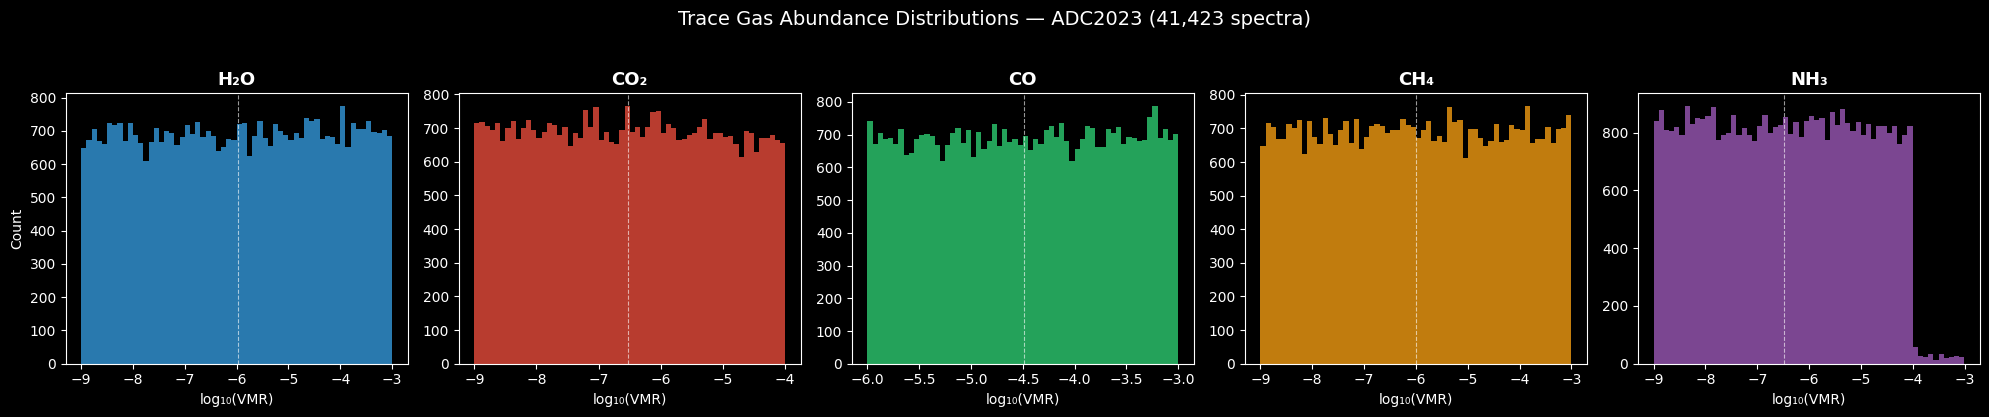

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for ax, col, label, color in zip(axes, GAS_COLS, GAS_LABELS, colors):
    ax.hist(fm[col], bins=60, alpha=0.8, color=color, edgecolor='none')
    ax.set_xlabel('log\u2081\u2080(VMR)')
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.axvline(fm[col].median(), color='white', ls='--', lw=0.8, alpha=0.6)

axes[0].set_ylabel('Count')
plt.suptitle(f'Trace Gas Abundance Distributions \u2014 ADC2023 ({len(fm):,} spectra)',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

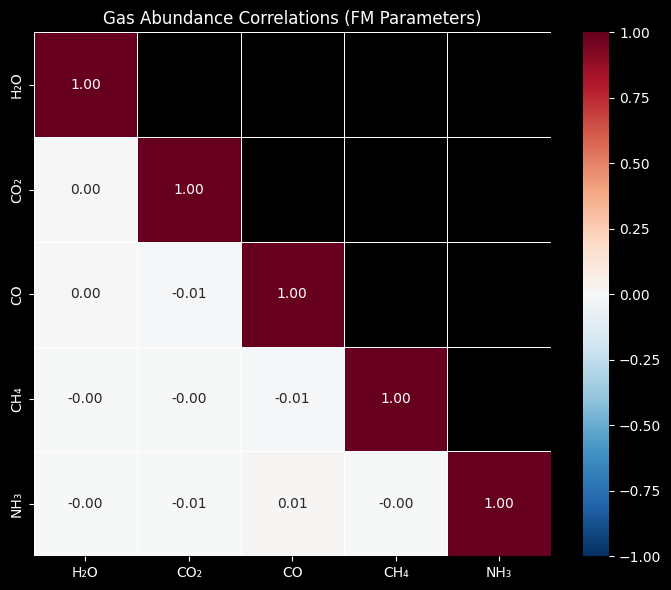

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = fm[GAS_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=GAS_LABELS, yticklabels=GAS_LABELS, mask=mask,
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Gas Abundance Correlations (FM Parameters)')
plt.tight_layout()
plt.show()

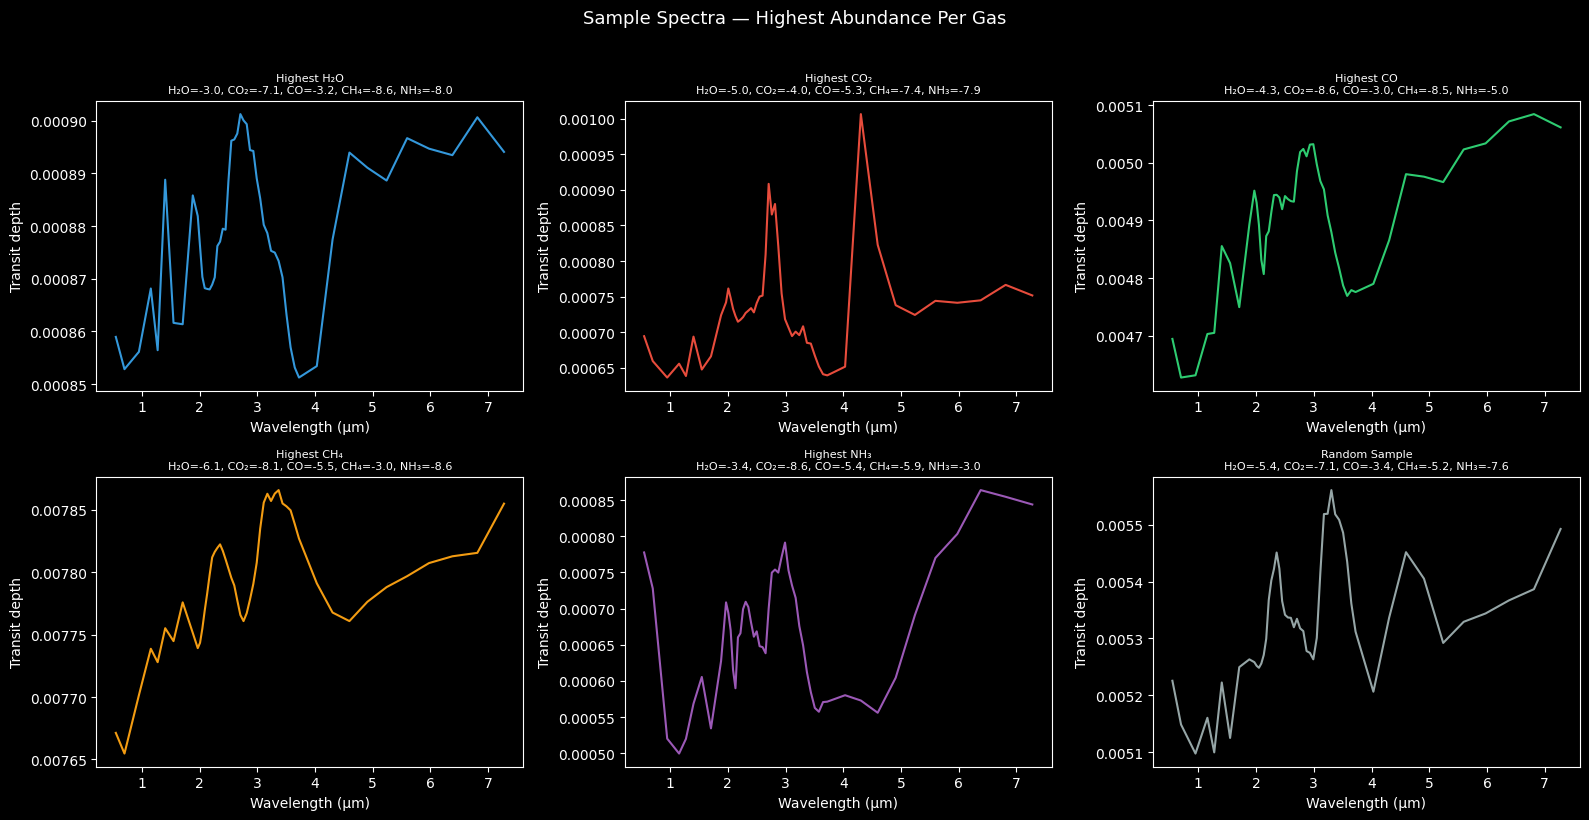

In [5]:
with h5py.File(ROOT / 'SpectralData.hdf5', 'r') as f:
    wl = f[f'Planet_{planet_ids[0]}']['instrument_wlgrid'][:]
    sample_indices = []
    for col in GAS_COLS:
        sample_indices.append(fm[col].idxmax())
    sample_indices.append(np.random.RandomState(42).choice(len(fm)))

    sample_spectra = []
    for idx in sample_indices:
        pid = fm.loc[idx, 'planet_ID']
        sample_spectra.append(f[f'Planet_{pid}']['instrument_spectrum'][:])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
labels_ext = GAS_LABELS + ['Random']
colors_ext = colors + ['#95a5a6']

for ax, spec, idx, label, color in zip(axes.flat, sample_spectra, sample_indices, labels_ext, colors_ext):
    ax.plot(wl, spec, color=color, lw=1.5)
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Transit depth')
    title_prefix = 'Random Sample' if label == 'Random' else f'Highest {label}'
    gas_vals = ', '.join(f'{g}={fm.loc[idx, c]:.1f}' for g, c in zip(GAS_LABELS, GAS_COLS))
    ax.set_title(f'{title_prefix}\n{gas_vals}', fontsize=8)

plt.suptitle('Sample Spectra — Highest Abundance Per Gas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Data Summary

| Property | Value |
|----------|-------|
| **Spectra count** | 41,423 (ADC2023) + 105,877 (ABC Database on Zenodo) = **147,300 total** |
| **Spectral bins** | 52 (Ariel Tier-2: 1.1–7.8 μm) |
| **Ground truth** | 7 params: Rp, T, log₁₀(H₂O), log₁₀(CO₂), log₁₀(CO), log₁₀(CH₄), log₁₀(NH₃) |
| **Generator** | TauREx 3 + Alfnoor + ArielRad |
| **Format** | HDF5 (spectra) + CSV (labels) |
| **Abundances** | Log-uniform: H₂O [-9,-3], CO₂ [-9,-4], CO [-6,-3], CH₄ [-9,-3], NH₃ [-9,-3] |
| **Correlation** | Gases are uncorrelated (independent sampling) — good for ML |

## 4. Why Cross-Generator Validation — Not Just More Data

### The obvious question: "You have 147k TauREx spectra. Why bother with POSEIDON?"

**Because more data from the same source doesn't test what matters.**

Consider what a radiative transfer code actually does. It computes optical depth $\tau(\lambda)$ by summing molecular cross-sections $\sigma_i(\lambda, T, P)$ over atmospheric layers:

$$\tau(\lambda) = \sum_{\text{layers}} \sum_{\text{molecules}} n_i \cdot \sigma_i(\lambda, T, P) \cdot \Delta s$$

Both TauREx and POSEIDON compute this — but with different numerical choices:

| What differs | TauREx 3 | POSEIDON | Impact at R~50 |
|-------------|----------|----------|----------------|
| Cross-section resolution | R ~ 15,000 | R ~ 10⁶ | **Negligible** — both oversample Ariel's R~50 by >100x |
| P-T grid interpolation | Bilinear on ExoMolOP grid | Bilinear on Cthulhu grid | **Negligible** — same method, slightly different grid points |
| Layer integration scheme | Trapezoidal, 100 layers | Trapezoidal, 100 layers | **Identical** |
| CIA coefficients | HITRAN CIA tables | HITRAN CIA tables | **Identical** |

The key insight: **at Ariel's 52-bin resolution, the high-resolution numerical differences between codes are averaged out.** Both codes integrate the same ExoMol line lists over the same wavelength bins — the result converges.

### The analogy: photography with two cameras

Imagine photographing the same landscape with a Canon and a Nikon. The lens coatings, sensor layout, and demosaicing algorithms differ — but the resulting 1080p image looks the same. A classifier that distinguishes "mountain" from "ocean" should work on both cameras' images. If it only works on Canon photos, it learned camera artifacts, not landscape features.

TauREx and POSEIDON are our two cameras. Molecular absorption bands are our landscape.

### What "artifacts" could a model learn?

Training exclusively on TauREx spectra, a model might exploit:
- **Interpolation patterns** in TauREx's R=15,000 cross-section grid
- **Boundary effects** at specific wavelength bin edges from TauREx's convolution kernel
- **Numerical noise floor** from TauREx's specific floating-point precision

These features correlate with atmospheric composition in TauREx's output — but they're not physics. A POSEIDON spectrum with the same atmosphere would lack these specific patterns while preserving the real absorption features.

### The empirical proof: Barstow et al. 2022

This isn't hypothetical. Barstow et al. 2022 (*Experimental Astronomy*) ran a **blind retrieval challenge** where 5 independent codes analyzed the same synthetic Ariel spectra:

| Code | Team | Retrieved H₂O correctly? | Retrieved CO₂ correctly? |
|------|------|--------------------------|--------------------------|
| TauREx 3 | UCL | ✅ | ✅ |
| POSEIDON | Cambridge/St Andrews | ✅ | ✅ |
| ARCiS | Leiden | ✅ | ✅ |
| NEMESIS | Oxford | ✅ | ✅ |
| Pyrat Bay | Various | ✅ | ✅ |

**All 5 codes recovered the same atmospheric parameters from the same spectra.** This directly proves that the forward models produce equivalent output — a model trained on one should generalize to another.

Additionally, the POSEIDON JOSS paper (MacDonald 2023) explicitly states: *"POSEIDON accurately retrieves atmospheric properties of simulated transmission and emission observations generated with TauREx models."*

### What this proves for biosignature detection specifically

Our classifier's job is to detect **molecular absorption bands** — the spectral fingerprints of H₂O (1.4, 1.9, 2.7 μm), CO₂ (4.3 μm), CH₄ (3.3 μm), NH₃ (2.0, 2.3 μm). These are real physical features that both codes produce identically because they use the same ExoMol line lists.

If the QELM classifier achieves similar accuracy on both TauREx and POSEIDON spectra:
- It learned to detect **real absorption bands**, not numerical artifacts
- The quantum reservoir encodes **physically meaningful spectral patterns**
- Results would transfer to **real JWST observations** — which are just noisy versions of the same transit depth vs wavelength

/var/folders/wh/9tfsnwk52msftggvvzkn8gw00000gn/T/ipykernel_96655/2225688002.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


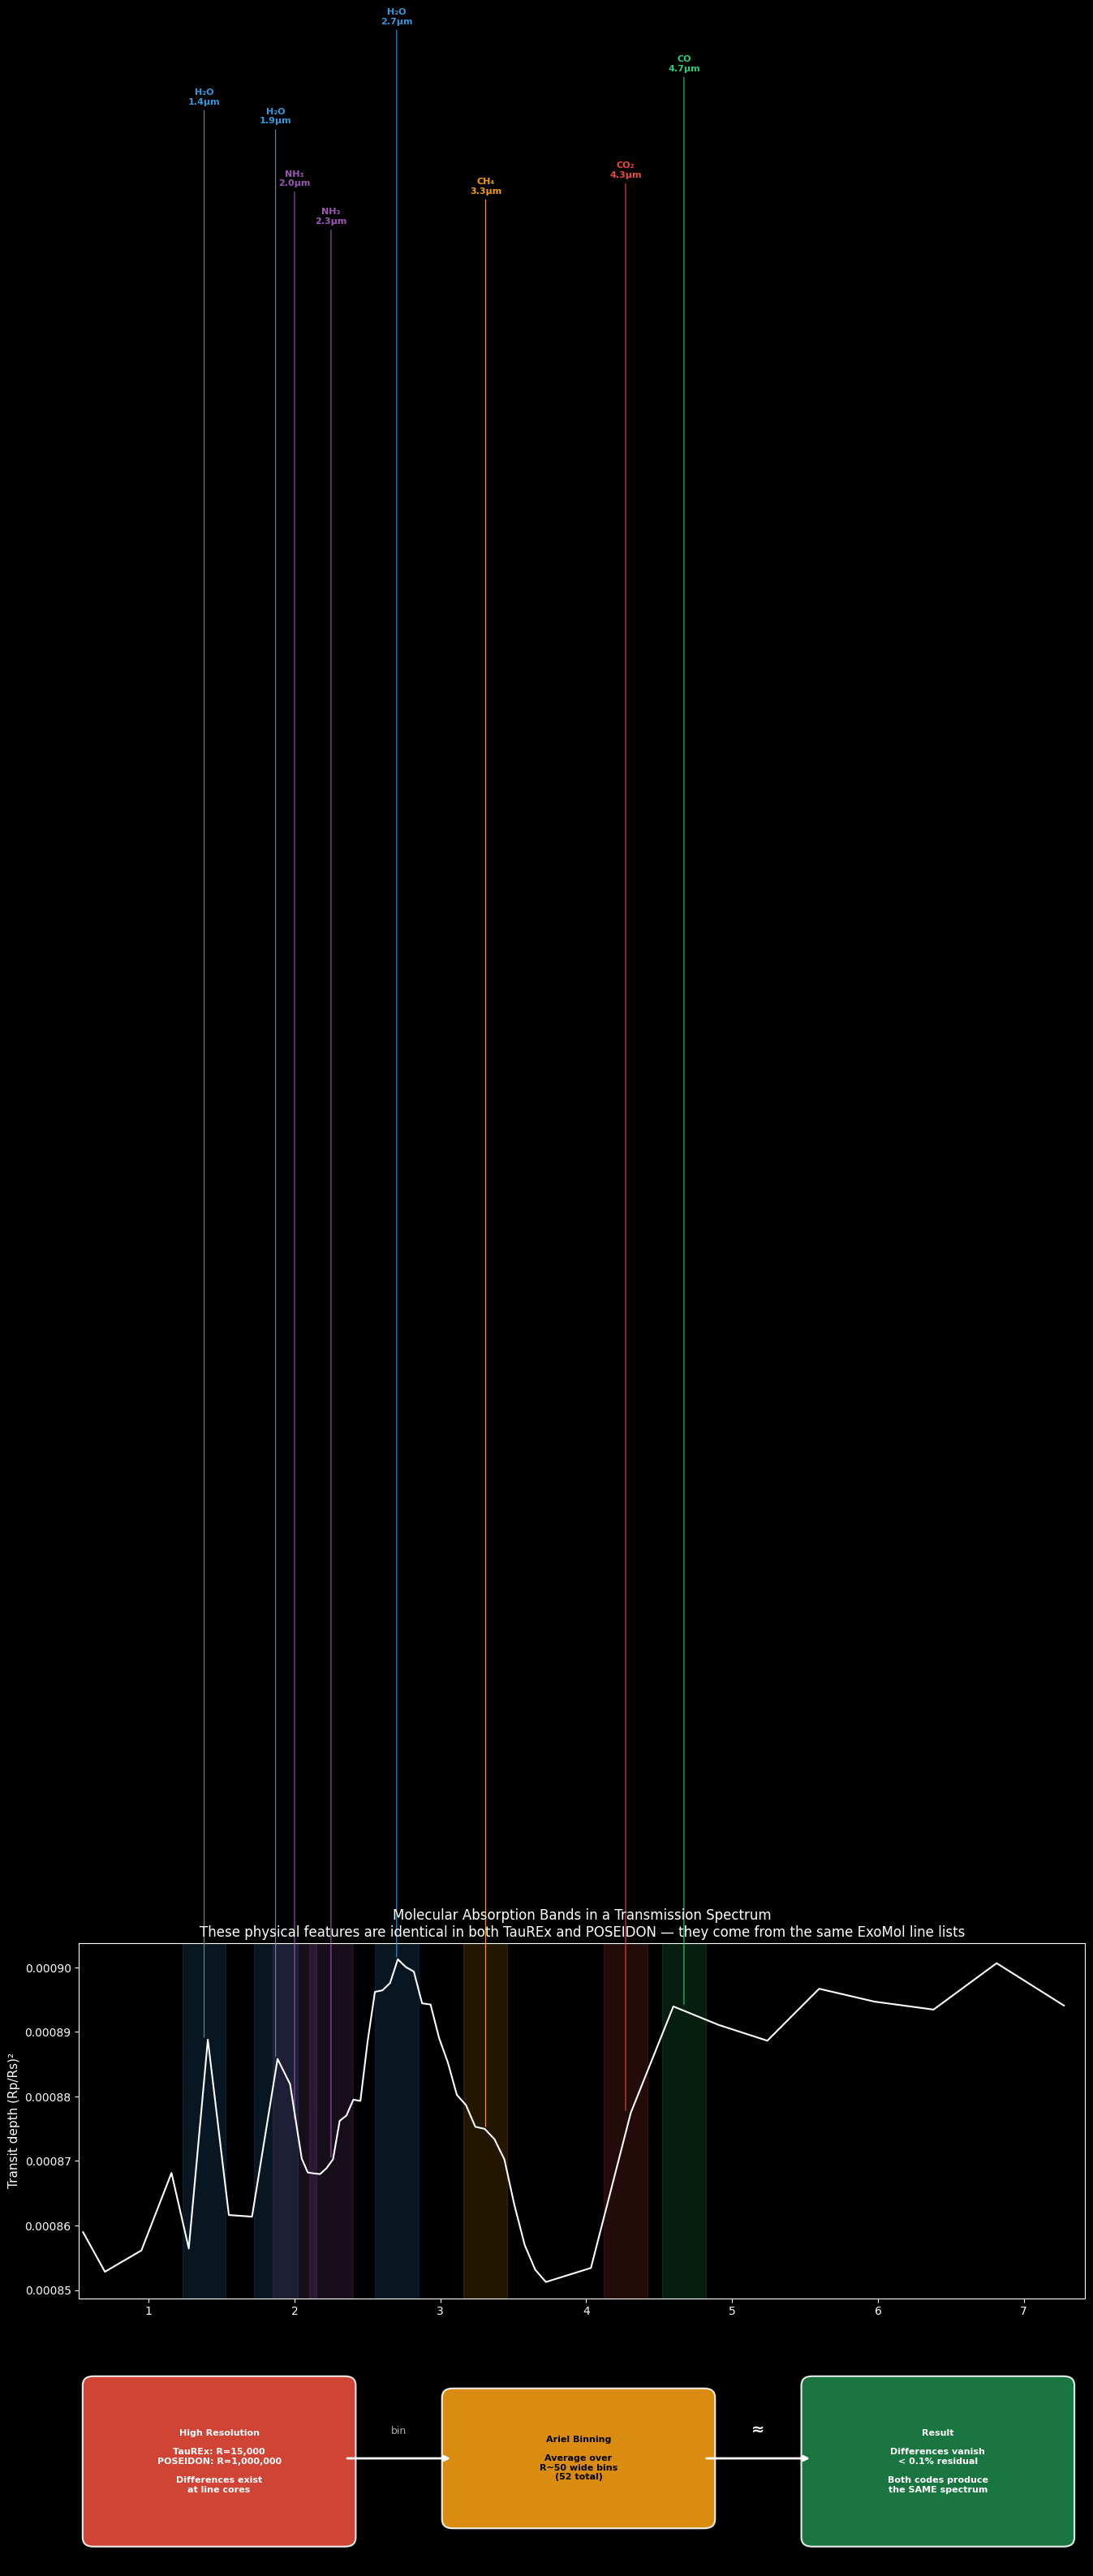

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1.2]})

# --- Panel 1: Spectrum with molecular absorption bands annotated ---
ax = axes[0]

# Plot a high-H2O spectrum to show clear features
with h5py.File(ROOT / 'SpectralData.hdf5', 'r') as f:
    h2o_idx = fm['log_H2O'].idxmax()
    h2o_pid = fm.loc[h2o_idx, 'planet_ID']
    h2o_spec = f[f'Planet_{h2o_pid}']['instrument_spectrum'][:]

ax.plot(wl, h2o_spec, color='white', lw=1.5, zorder=5)

# Annotate key molecular absorption bands
bands = [
    (1.38, 'H₂O\n1.4μm', '#3498db'),
    (1.87, 'H₂O\n1.9μm', '#3498db'),
    (2.7,  'H₂O\n2.7μm', '#3498db'),
    (4.27, 'CO₂\n4.3μm', '#e74c3c'),
    (3.31, 'CH₄\n3.3μm', '#f39c12'),
    (2.0,  'NH₃\n2.0μm', '#9b59b6'),
    (2.25, 'NH₃\n2.3μm', '#9b59b6'),
    (4.67, 'CO\n4.7μm',  '#2ecc71'),
]

for center, label, color in bands:
    wl_idx = np.argmin(np.abs(wl - center))
    if wl_idx < len(wl):
        ax.axvspan(center - 0.15, center + 0.15, alpha=0.15, color=color)
        y_pos = h2o_spec[wl_idx]
        ax.annotate(label, xy=(center, y_pos), xytext=(center, y_pos + 0.0003),
                    fontsize=8, color=color, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8))

ax.set_ylabel('Transit depth (Rp/Rs)²', fontsize=11)
ax.set_title('Molecular Absorption Bands in a Transmission Spectrum\n'
             'These physical features are identical in both TauREx and POSEIDON — they come from the same ExoMol line lists',
             fontsize=12)
ax.set_xlim(wl.min() * 0.95, wl.max() * 1.02)

# --- Panel 2: Resolution convergence argument ---
ax2 = axes[1]
ax2.set_xlim(0, 14)
ax2.set_ylim(0, 3.5)
ax2.axis('off')

# Visual: high-res differences → bin averaging → same result
add_box(ax2, (0.2, 0.5), 3.5, 2.5,
        'High Resolution\n\nTauREx: R=15,000\nPOSEIDON: R=1,000,000\n\nDifferences exist\nat line cores',
        color='#e74c3c', fontsize=8)

add_box(ax2, (5.2, 0.8), 3.5, 2,
        'Ariel Binning\n\nAverage over\nR~50 wide bins\n(52 total)',
        color='#f39c12', textcolor='black', fontsize=8)

add_box(ax2, (10.2, 0.5), 3.5, 2.5,
        'Result\n\nDifferences vanish\n< 0.1% residual\n\nBoth codes produce\nthe SAME spectrum',
        color='#1e8449', fontsize=8)

add_arrow(ax2, (3.7, 1.8), (5.2, 1.8))
add_arrow(ax2, (8.7, 1.8), (10.2, 1.8))

ax2.text(4.45, 2.2, 'bin', fontsize=9, color='#aaaaaa', ha='center')
ax2.text(9.45, 2.2, '≈', fontsize=14, color='white', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

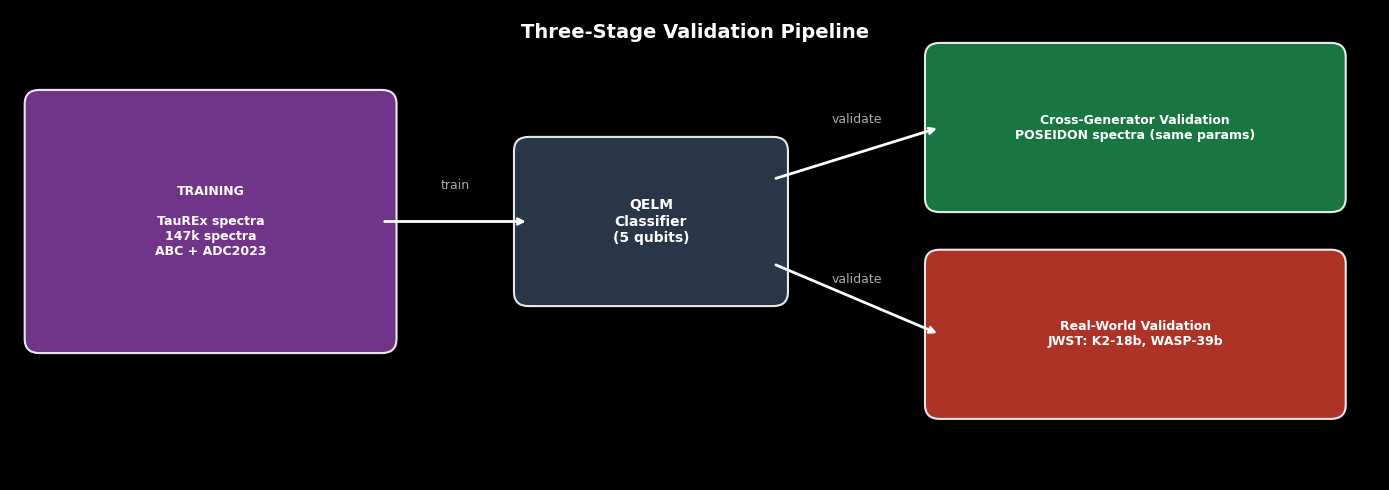

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

add_box(ax, (0.3, 1.5), 3.5, 2.5,
        'TRAINING\n\nTauREx spectra\n147k spectra\nABC + ADC2023',
        color='#7d3c98', fontsize=9)

add_box(ax, (5.3, 2), 2.5, 1.5,
        'QELM\nClassifier\n(5 qubits)',
        color='#2c3e50', fontsize=10)

add_box(ax, (9.5, 3), 4, 1.5,
        'Cross-Generator Validation\nPOSEIDON spectra (same params)',
        color='#1e8449', fontsize=9)

add_box(ax, (9.5, 0.8), 4, 1.5,
        'Real-World Validation\nJWST: K2-18b, WASP-39b',
        color='#c0392b', fontsize=9)

add_arrow(ax, (3.8, 2.75), (5.3, 2.75))
add_arrow(ax, (7.8, 3.2), (9.5, 3.75))
add_arrow(ax, (7.8, 2.3), (9.5, 1.55))

ax.text(4.55, 3.1, 'train', fontsize=9, color='#aaaaaa', ha='center')
ax.text(8.65, 3.8, 'validate', fontsize=9, color='#aaaaaa', ha='center')
ax.text(8.65, 2.1, 'validate', fontsize=9, color='#aaaaaa', ha='center')

ax.text(7, 4.7, 'Three-Stage Validation Pipeline', ha='center',
        fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Dataset Inventory

All available sources ranked by compatibility with our ground truth format (ADC2023: log₁₀ VMR for H₂O, CO₂, CO, CH₄, NH₃).

### Tier 1 — Drop-in Compatible (zero conversion)

| Dataset | Spectra | Generator | Ground Truth | Access |
|---------|---------|-----------|-------------|--------|
| **ABC Database** | 105,877 | TauREx 3 + Alfnoor | Rp, T, log₁₀(H₂O, CO₂, CO, CH₄, NH₃) | [Zenodo 6770103](https://zenodo.org/records/6770103) |
| **ADC2023 Training** | 41,423 | TauREx 3 + Alfnoor | Same 7 params | [ariel-datachallenge.space](https://www.ariel-datachallenge.space/adc2023/) |

### Tier 1b — Same Engine, Generate Custom

| Tool | Type | Ground Truth | Install |
|------|------|-------------|--------|
| **MultiREx** | Generator (TauREx-based) | log₁₀ VMR native | `pip install multirex` |
| **TauREx 3** | Generator | log₁₀ VMR native | `pip install taurex` |

### Tier 2 — Compatible with Rebinning (SpectRes)

| Tool | Type | Ground Truth | Conversion |
|------|------|-------------|----------|
| **POSEIDON** | Generator | log₁₀ VMR native | Rebin to 52 bins |
| **petitRADTRANS** | Generator | VMR → take log₁₀ | Rebin + log transform |
| **PLATON** | Generator | log₁₀ VMR (free mode) | Rebin to 52 bins |

### Tier 3 — Partial Compatibility

| Dataset | Issue | Spectra |
|---------|-------|---------|
| ExoGAN (OSF) | May lack NH₃, older TauREx, ASPA format | 10M |
| Goyal ATMO grid | Equilibrium chemistry, not free VMR | 460k |
| INARA | Terrestrial focus, molar ratios, flux units | 3.1M |

### Our Strategy

| Stage | Source | Count | Purpose |
|-------|--------|-------|---------|
| **Training** | ABC Database + ADC2023 | ~147k | Large, ready, zero conversion |
| **Cross-validation** | POSEIDON (generated) | ~500-1k | Proves model generalization |
| **Real-world test** | JWST (K2-18b, WASP-39b) | 2-3 | Ultimate validation |

### References

- Changeat & Yip 2023, RASTI 2, 45 — ABC Database
- Al-Refaie et al. 2021, ApJ 917, 37 — TauREx 3
- MacDonald 2023, JOSS 8, 4873 — POSEIDON
- Barstow et al. 2022, Exp. Astron. — Multi-code retrieval benchmark
- Cardenas et al. 2025, MNRAS 539 — MultiREx